# Notebook 05: Post-hoc analysis of omnibus-significant variables

This notebook runs follow-up analyses **only for metadata variables that survived FDR correction in the omnibus permutation analysis** (Notebook 05). For each surviving variable, two follow-ups are performed:

1. **Per-component statistical tests** — which NMF component(s) drive the omnibus signal? Tests use Spearman correlation (continuous), Mann–Whitney U (binary), or Kruskal–Wallis H (multi-category), with Benjamini–Hochberg FDR correction across the components for that variable.

2. **Cluster × variable alignment** — does the K-means cluster assignment align with the same variable? Tests use Fisher's exact (binary), Mann–Whitney U (continuous), or chi-square (multi-category).

These tests are **conditional follow-ups** — they characterize the signal already identified by the omnibus analysis rather than making independent confirmatory claims. p-values from this notebook should be interpreted as exploratory localization, not as new significance findings.

**Inputs:**
- `outputs/nmf_W.csv` — participant × component embedding
- `outputs/metadata.csv` — aligned metadata
- `outputs/omnibus_results.csv` — omnibus test results (must exist; from Notebook 05)
- `outputs/cluster_assignments.csv` — cluster labels (must exist; from Notebook 03)

**Outputs:**
- `outputs/posthoc_per_component.csv` — per-component tests for surviving variables
- `outputs/posthoc_cluster.csv` — cluster × variable tests for surviving variables
- `outputs/posthoc_summary.txt` — human-readable summary

## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(".").resolve().parent
OUTPUT_DIR = PROJECT_ROOT / "outputs"

FDR_ALPHA = 0.05

## Variable classification

Editable if needed.

In [2]:
VAR_TYPES = {
    "Age":                                  "continuous",
    "Gender":                               "binary",
    "Residential Area (Urban/Rural)":       "binary",
    "From City":                            "binary",
    "Single/NotSingle":                     "binary",
    "Education":                            "multi",
    "Field of Study":                       "multi",
    "Occupation":                           "multi",
    "# of LanguagesSpeak":                  "continuous",
    "UsedToDoSport":                        "binary",
    "NowDoingSports_aWeek":                 "continuous",
    "PlayingAnInstrument":                  "binary",
    "History of Neurological Disorders":    "binary",
    "Medication Usage":                     "binary",
    "Average Sleep Hours per Night":        "continuous",
    "Smoking (0,1,2,3)":                    "continuous",
    "Alchocol (0,1,2,3)":                   "continuous",
}

## Load inputs and identify omnibus-surviving variables

In [3]:
W = pd.read_csv(OUTPUT_DIR / "nmf_W.csv", index_col="participant_id")
metadata = pd.read_csv(OUTPUT_DIR / "metadata.csv")
metadata = metadata.set_index("participant_id").reindex(W.index)

omnibus = pd.read_csv(OUTPUT_DIR / "omnibus_results.csv")
clusters = pd.read_csv(OUTPUT_DIR / "cluster_assignments.csv")
clusters = clusters.set_index("participant_id").reindex(W.index)

print(f"W shape:        {W.shape}")
print(f"Metadata shape: {metadata.shape}")
print(f"Cluster shape:  {clusters.shape}")
print(f"Components:     {list(W.columns)}")

# Identify which variables survived omnibus FDR
surviving = omnibus[omnibus["significant_fdr"] == True].copy()
print(f"\nOmnibus-significant variables (FDR α={FDR_ALPHA}): {len(surviving)}")
if len(surviving) == 0:
    print("\n[NOTE] No variables survived omnibus FDR. Post-hoc analyses will not be performed.")
    print("If this is unexpected, verify omnibus_results.csv reflects the current pipeline run.")
else:
    print("\nVariables to follow up on:")
    print(surviving[["variable", "type", "n", "observed_stat", "p_perm", "p_fdr"]].round(4).to_string(index=False))

W shape:        (86, 5)
Metadata shape: (86, 17)
Cluster shape:  (86, 1)
Components:     ['comp_1', 'comp_2', 'comp_3', 'comp_4', 'comp_5']

Omnibus-significant variables (FDR α=0.05): 1

Variables to follow up on:
variable   type  n  observed_stat  p_perm  p_fdr
  Gender binary 86         0.2742  0.0002 0.0034


## Per-component follow-up tests

For each surviving omnibus variable, test the association of that variable with each of the NMF components individually. Apply Benjamini–Hochberg FDR correction within the variable (i.e., across the components for that variable).

In [4]:
def rank_biserial(u, n1, n2):
    return 1 - (2 * u) / (n1 * n2)

def epsilon_squared(h, n):
    return h / (n - 1) if n > 1 else 0.0

per_component_rows = []

for _, omn_row in surviving.iterrows():
    var = omn_row["variable"]
    vtype = VAR_TYPES.get(var)
    if vtype is None:
        print(f"[SKIP] {var}: not in VAR_TYPES dictionary")
        continue

    var_rows = []
    for comp in W.columns:
        sub = pd.DataFrame({"loading": W[comp], "var": metadata[var]}).dropna()
        n = len(sub)
        if n < 5:
            var_rows.append({"variable": var, "type": vtype, "component": comp, "n": n,
                             "test": "skipped", "statistic": np.nan, "effect_size": np.nan,
                             "p_raw": np.nan, "note": "insufficient n"})
            continue

        if vtype == "continuous":
            x = pd.to_numeric(sub["var"], errors="coerce")
            mask = ~x.isna()
            if mask.sum() < 5:
                var_rows.append({"variable": var, "type": vtype, "component": comp, "n": int(mask.sum()),
                                 "test": "spearman", "statistic": np.nan, "effect_size": np.nan,
                                 "p_raw": np.nan, "note": "insufficient numeric data"})
                continue
            rho, p = stats.spearmanr(sub.loc[mask, "loading"], x[mask])
            var_rows.append({"variable": var, "type": vtype, "component": comp, "n": int(mask.sum()),
                             "test": "spearman", "statistic": float(rho), "effect_size": float(rho),
                             "p_raw": float(p), "note": ""})

        elif vtype == "binary":
            groups = sub["var"].unique()
            if len(groups) != 2:
                var_rows.append({"variable": var, "type": vtype, "component": comp, "n": n,
                                 "test": "mann-whitney", "statistic": np.nan, "effect_size": np.nan,
                                 "p_raw": np.nan, "note": f"expected 2 groups, found {len(groups)}"})
                continue
            g1 = sub.loc[sub["var"] == groups[0], "loading"].values
            g2 = sub.loc[sub["var"] == groups[1], "loading"].values
            u, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
            r = rank_biserial(u, len(g1), len(g2))
            var_rows.append({"variable": var, "type": vtype, "component": comp, "n": n,
                             "test": "mann-whitney", "statistic": float(u), "effect_size": float(r),
                             "p_raw": float(p),
                             "note": f"{groups[0]}(n={len(g1)}) vs {groups[1]}(n={len(g2)})"})

        elif vtype == "multi":
            groups = sub["var"].unique()
            group_values = [sub.loc[sub["var"] == g, "loading"].values for g in groups]
            valid_groups = [g for g in group_values if len(g) >= 2]
            if len(valid_groups) < 2:
                var_rows.append({"variable": var, "type": vtype, "component": comp, "n": n,
                                 "test": "kruskal", "statistic": np.nan, "effect_size": np.nan,
                                 "p_raw": np.nan, "note": "insufficient groups with n>=2"})
                continue
            h, p = stats.kruskal(*valid_groups)
            eps2 = epsilon_squared(h, sum(len(g) for g in valid_groups))
            var_rows.append({"variable": var, "type": vtype, "component": comp, "n": n,
                             "test": "kruskal", "statistic": float(h), "effect_size": float(eps2),
                             "p_raw": float(p), "note": f"{len(valid_groups)} groups"})

    # Apply FDR within this variable's components
    var_df = pd.DataFrame(var_rows)
    if var_df["p_raw"].notna().any():
        valid_mask = var_df["p_raw"].notna()
        p_valid = var_df.loc[valid_mask, "p_raw"].values
        reject, p_fdr, _, _ = multipletests(p_valid, alpha=FDR_ALPHA, method="fdr_bh")
        var_df.loc[valid_mask, "p_fdr"] = p_fdr
        var_df.loc[valid_mask, "significant_fdr"] = reject
    else:
        var_df["p_fdr"] = np.nan
        var_df["significant_fdr"] = False
    var_df["significant_fdr"] = var_df["significant_fdr"].fillna(False)

    per_component_rows.append(var_df)

if per_component_rows:
    per_component_df = pd.concat(per_component_rows, ignore_index=True)
    per_component_df = per_component_df.sort_values(["variable", "p_raw"])
    per_component_df.to_csv(OUTPUT_DIR / "posthoc_per_component.csv", index=False)

    print("Per-component follow-up results (FDR within each variable):")
    cols = ["variable", "component", "test", "n", "effect_size", "p_raw", "p_fdr", "significant_fdr"]
    print(per_component_df[cols].round(4).to_string(index=False))
else:
    per_component_df = pd.DataFrame()
    print("No per-component follow-up performed.")

Per-component follow-up results (FDR within each variable):
variable component         test  n  effect_size  p_raw  p_fdr  significant_fdr
  Gender    comp_1 mann-whitney 86       0.5768 0.0000 0.0000             True
  Gender    comp_4 mann-whitney 86      -0.3144 0.0122 0.0304             True
  Gender    comp_2 mann-whitney 86       0.1331 0.2898 0.4830            False
  Gender    comp_5 mann-whitney 86      -0.0574 0.6498 0.7523            False
  Gender    comp_3 mann-whitney 86       0.0400 0.7523 0.7523            False


## Cluster × variable follow-up

For each surviving omnibus variable, test whether the K-means cluster assignment also aligns with that variable. Test selection follows the variable's measurement scale:

- **Binary outcomes** → Fisher's exact test (preferred over chi-square for small cell counts)
- **Continuous outcomes** → Mann–Whitney U (between clusters)
- **Multi-category outcomes** → chi-square test of independence (Fisher's exact is impractical beyond 2×2)

No multiple-testing correction is applied across variables here because the number of tests equals the number of omnibus-surviving variables and each is a single targeted follow-up.

In [5]:
cluster_rows = []

if len(clusters["cluster"].unique()) < 2:
    print("Only one cluster present — cluster × variable tests cannot be performed.")
else:
    merged = pd.DataFrame({"cluster": clusters["cluster"]})
    merged = merged.merge(metadata, left_index=True, right_index=True, how="inner")

    for _, omn_row in surviving.iterrows():
        var = omn_row["variable"]
        vtype = VAR_TYPES.get(var)
        if vtype is None:
            continue

        sub = merged[["cluster", var]].dropna()
        n = len(sub)
        if n < 10:
            cluster_rows.append({"variable": var, "type": vtype, "test": "skipped", "n": n,
                                 "statistic": np.nan, "p_raw": np.nan, "note": "insufficient n"})
            continue

        if vtype == "binary":
            ct = pd.crosstab(sub["cluster"], sub[var])
            if ct.shape == (2, 2):
                odds, p = stats.fisher_exact(ct.values)
                cluster_rows.append({"variable": var, "type": vtype, "test": "fisher_exact", "n": n,
                                     "statistic": float(odds), "p_raw": float(p),
                                     "note": f"contingency: {ct.values.tolist()}"})
            else:
                chi2, p, dof, _ = stats.chi2_contingency(ct)
                cluster_rows.append({"variable": var, "type": vtype, "test": "chi2", "n": n,
                                     "statistic": float(chi2), "p_raw": float(p),
                                     "note": f"shape={ct.shape}, dof={dof}"})

        elif vtype == "continuous":
            x = pd.to_numeric(sub[var], errors="coerce")
            valid_sub = sub.assign(x=x).dropna(subset=["x"])
            groups = sorted(valid_sub["cluster"].unique())
            if len(groups) != 2:
                cluster_rows.append({"variable": var, "type": vtype, "test": "mann-whitney", "n": len(valid_sub),
                                     "statistic": np.nan, "p_raw": np.nan,
                                     "note": f"need exactly 2 clusters, got {len(groups)}"})
                continue
            g0 = valid_sub.loc[valid_sub["cluster"] == groups[0], "x"].values
            g1 = valid_sub.loc[valid_sub["cluster"] == groups[1], "x"].values
            u, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
            cluster_rows.append({"variable": var, "type": vtype, "test": "mann-whitney", "n": len(valid_sub),
                                 "statistic": float(u), "p_raw": float(p),
                                 "note": f"cluster {groups[0]} median={np.median(g0):.3f}, "
                                         f"cluster {groups[1]} median={np.median(g1):.3f}"})

        elif vtype == "multi":
            ct = pd.crosstab(sub["cluster"], sub[var])
            chi2, p, dof, _ = stats.chi2_contingency(ct)
            cluster_rows.append({"variable": var, "type": vtype, "test": "chi2", "n": n,
                                 "statistic": float(chi2), "p_raw": float(p),
                                 "note": f"shape={ct.shape}, dof={dof}"})

if cluster_rows:
    cluster_df = pd.DataFrame(cluster_rows)
    cluster_df.to_csv(OUTPUT_DIR / "posthoc_cluster.csv", index=False)
    print("Cluster × variable tests (no correction; one test per omnibus-surviving variable):")
    print(cluster_df[["variable", "type", "test", "n", "statistic", "p_raw", "note"]].round(4).to_string(index=False))
else:
    cluster_df = pd.DataFrame()
    print("No cluster × variable tests performed.")

Cluster × variable tests (no correction; one test per omnibus-surviving variable):
variable   type         test  n  statistic  p_raw                              note
  Gender binary fisher_exact 86     1.4933 0.4752 contingency: [[32, 30], [10, 14]]


## Summary

In [6]:
summary_lines = []
summary_lines.append("=" * 60)
summary_lines.append("POST-HOC ANALYSIS SUMMARY")
summary_lines.append("=" * 60)
summary_lines.append(f"\nN participants:               {len(W)}")
summary_lines.append(f"N components:                 {len(W.columns)}")
summary_lines.append(f"N omnibus-surviving variables: {len(surviving)}")
summary_lines.append(f"FDR threshold (within variable): {FDR_ALPHA}")

if len(surviving) == 0:
    summary_lines.append("\nNo variables survived omnibus FDR. No post-hoc analyses were performed.")
else:
    summary_lines.append("\nOmnibus-surviving variables:")
    for _, row in surviving.iterrows():
        summary_lines.append(
            f"  {row['variable']:40s} | observed_stat={row['observed_stat']:.4f} | p_fdr={row['p_fdr']:.4f}"
        )

    if not per_component_df.empty:
        sig_pc = per_component_df[per_component_df["significant_fdr"] == True]
        summary_lines.append(f"\nPer-component results: {len(sig_pc)} component-variable pairs significant after within-variable FDR")
        for _, row in sig_pc.iterrows():
            summary_lines.append(
                f"  {row['component']:8s} <-> {row['variable']:40s} | {row['test']:15s} | "
                f"effect={row['effect_size']:.3f} | p_fdr={row['p_fdr']:.4f}"
            )

    if not cluster_df.empty:
        summary_lines.append("\nCluster × variable results (uncorrected p-values):")
        for _, row in cluster_df.iterrows():
            sig_marker = "  *" if row["p_raw"] < FDR_ALPHA else "   "
            summary_lines.append(
                f" {sig_marker}{row['variable']:40s} | {row['test']:15s} | stat={row['statistic']:.4f} | p={row['p_raw']:.4f}"
            )

summary_lines.append("\nFiles saved:")
summary_lines.append("  posthoc_per_component.csv")
summary_lines.append("  posthoc_cluster.csv")
summary_lines.append("  posthoc_summary.txt")

summary_text = "\n".join(summary_lines)
print(summary_text)

with open(OUTPUT_DIR / "posthoc_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

POST-HOC ANALYSIS SUMMARY

N participants:               86
N components:                 5
N omnibus-surviving variables: 1
FDR threshold (within variable): 0.05

Omnibus-surviving variables:
  Gender                                   | observed_stat=0.2742 | p_fdr=0.0034

Per-component results: 2 component-variable pairs significant after within-variable FDR
  comp_1   <-> Gender                                   | mann-whitney    | effect=0.577 | p_fdr=0.0000
  comp_4   <-> Gender                                   | mann-whitney    | effect=-0.314 | p_fdr=0.0304

Cluster × variable results (uncorrected p-values):
    Gender                                   | fisher_exact    | stat=1.4933 | p=0.4752

Files saved:
  posthoc_per_component.csv
  posthoc_cluster.csv
  posthoc_summary.txt


## Optional: per-variable visualization

For each surviving variable that has a significant per-component association, generate a visualization showing the component loadings stratified by variable level.

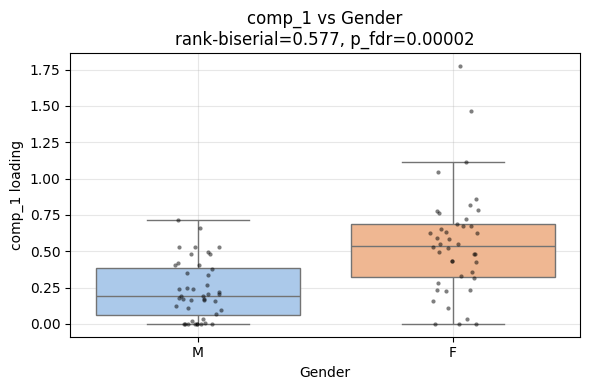

Saved posthoc_comp_1_vs_Gender.png


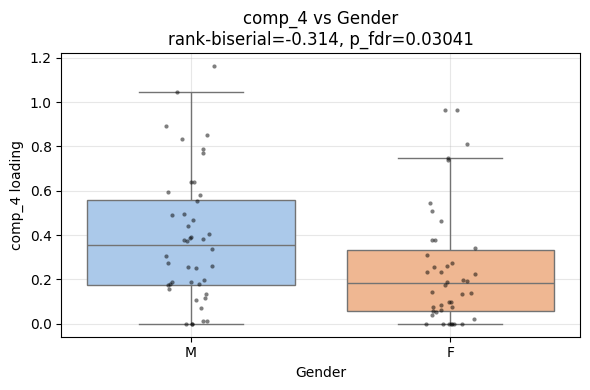

Saved posthoc_comp_4_vs_Gender.png


In [8]:
import matplotlib.pyplot as plt

if per_component_df.empty:
    print("No per-component results to visualize.")
else:
    sig_pc = per_component_df[per_component_df["significant_fdr"] == True]
    if sig_pc.empty:
        print("No FDR-significant per-component results to visualize.")
    else:
        for _, row in sig_pc.iterrows():
            var = row["variable"]
            comp = row["component"]
            vtype = row["type"]

            fig, ax = plt.subplots(1, 1, figsize=(6, 4))
            data = pd.DataFrame({"loading": W[comp], "var": metadata[var]}).dropna()

            if vtype == "continuous":
                x = pd.to_numeric(data["var"], errors="coerce")
                mask = ~x.isna()
                ax.scatter(x[mask], data.loc[mask, "loading"], alpha=0.6, edgecolor="black")
                ax.set_xlabel(var)
                ax.set_ylabel(f"{comp} loading")
                ax.set_title(f"{comp} vs {var}\nrho={row['effect_size']:.3f}, p_fdr={row['p_fdr']:.5f}")
            else:
                import seaborn as sns
                sns.boxplot(data=data, x="var", y="loading", ax=ax, showfliers=False, palette="pastel")
                sns.stripplot(data=data, x="var", y="loading", ax=ax, color="black", alpha=0.5, size=3)
                ax.set_xlabel(var)
                ax.set_ylabel(f"{comp} loading")
                effect_label = "rank-biserial" if vtype == "binary" else "epsilon²"
                ax.set_title(f"{comp} vs {var}\n{effect_label}={row['effect_size']:.3f}, p_fdr={row['p_fdr']:.5f}")
            ax.grid(alpha=0.3)
            plt.tight_layout()
            fname = f"posthoc_{comp}_vs_{var.replace(' ', '_').replace('/', '_')}.png"
            plt.savefig(OUTPUT_DIR / fname, dpi=150, bbox_inches="tight")
            plt.show()
            print(f"Saved {fname}")